In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, norm
import seaborn as sns
import matplotlib as mpl

# Model definitions
MODELS = {
    "ST_PST19": dict(file="datafiles/ST_PST19", color="tab:pink",   label="Riley19: ST+PST"),
    "ST_PDT":   dict(file="datafiles/ST_PDT",   color="tab:blue",   label="Vinciguerra24: ST+PDT"),
    "ST_PST":   dict(file="datafiles/ST_PST",   color="tab:orange", label="Vinciguerra24: ST+PST"),
    "PDT_U":    dict(file="datafiles/PDT_U",    color="tab:green",  label="Vinciguerra24: PDT--U"),
    "ST_U":     dict(file="datafiles/ST_U",     color="tab:cyan",   label="Vinciguerra24: ST--U"),
    "2spot":    dict(file="datafiles/2spot",    color="tab:red",    label="Miller19: 2spot"),
    "3spot":    dict(file="datafiles/3spot",    color="tab:purple", label="Miller19: 3spot"),
    "PDT_U26": dict(file="datafiles/PDT_U26",  color="tab:olive",  label="Kini26: PDT--U"),
    "combined_posterior": dict(file="combined_posterior.txt", color="black", label="Combined Posterior")
}

# Data and sample stats
samples_MR = {}
M_med, M_lo, M_hi, M_16, M_84, S_Mi= {}, {}, {}, {}, {}, {}
R_med, R_lo, R_hi, R_16, R_84, S_Ri = {}, {}, {}, {}, {}, {}
KDEs_2D = {}

for key, meta in MODELS.items():
    filename = meta["file"]

    data = np.loadtxt(filename)
    M, R = data.T[0], data.T[1]
    samples_MR[key] = np.vstack([M, R])

    # Mass statistics
    M_med[key] = np.median(M)
    M_lo[key]  = np.min(M)
    M_hi[key]  = np.max(M)
    M_16[key] = np.percentile(M, 16)
    M_84[key] = np.percentile(M, 84)
    S_Mi[key]  = max(M_hi[key] - M_med[key],
                     M_med[key] - M_lo[key])

    # Radius statistics
    R_med[key] = np.median(R)
    R_lo[key]  = np.min(R)
    R_hi[key]  = np.max(R)
    R_16[key] = np.percentile(R, 16)
    R_84[key] = np.percentile(R, 84)
    S_Ri[key]  = max(R_hi[key] - R_med[key],
                     R_med[key] - R_lo[key])

    print(
        rf"{meta['label']}: "
        rf"M = {M_med[key]:.3f} (+{M_84[key] - M_med[key]:.3f}/-{M_med[key] - M_16[key]:.3f}), "
        rf"R = {R_med[key]:.3f} (+{R_84[key] - R_med[key]:.3f}/-{R_med[key] - R_16[key]:.3f})"
    )

    # KDEs
    KDEs_2D[key] = gaussian_kde(samples_MR[key], bw_method="silverman")

M_grid = np.linspace(0.95, 2.2, 100)
dM = M_grid[1] - M_grid[0]

R_grid = np.linspace(9.0, 17.0, 100)
dR = R_grid[1] - R_grid[0]
MM, RR = np.meshgrid(M_grid, R_grid, indexing="ij")
pos = np.vstack([MM.ravel(), RR.ravel()])

# Using dict is more convenient for the multi-dimensional case, g_dict = KDEs_2D normalized.
g_dict = {}
for key in MODELS:

    g = KDEs_2D[key](pos).reshape(MM.shape)
    g /= np.trapz(
            np.trapz(g, R_grid, axis=1),
            M_grid
        )
    g_dict[key] = g
g_stack = np.array([g_dict[key] for key in MODELS]) # shape: (Ndata, NM, NR)

Riley19: ST+PST: M = 1.289 (+0.174/-0.157), R = 12.574 (+1.368/-1.294)
Vinciguerra24: ST+PDT: M = 1.395 (+0.128/-0.117), R = 11.714 (+0.872/-0.826)
Vinciguerra24: ST+PST: M = 1.927 (+0.097/-0.124), R = 15.232 (+0.524/-0.843)
Vinciguerra24: PDT--U: M = 1.702 (+0.183/-0.190), R = 14.435 (+0.877/-1.046)
Vinciguerra24: ST--U: M = 1.883 (+0.132/-0.189), R = 15.117 (+0.637/-1.314)
Miller19: 2spot: M = 1.442 (+0.175/-0.159), R = 13.271 (+1.300/-1.149)
Miller19: 3spot: M = 1.440 (+0.153/-0.147), R = 13.012 (+1.253/-1.057)
Kini26: PDT--U: M = 1.435 (+0.204/-0.167), R = 12.678 (+1.309/-1.041)
Combined Posterior: M = 1.468 (+0.088/-0.076), R = 12.717 (+0.646/-0.566)


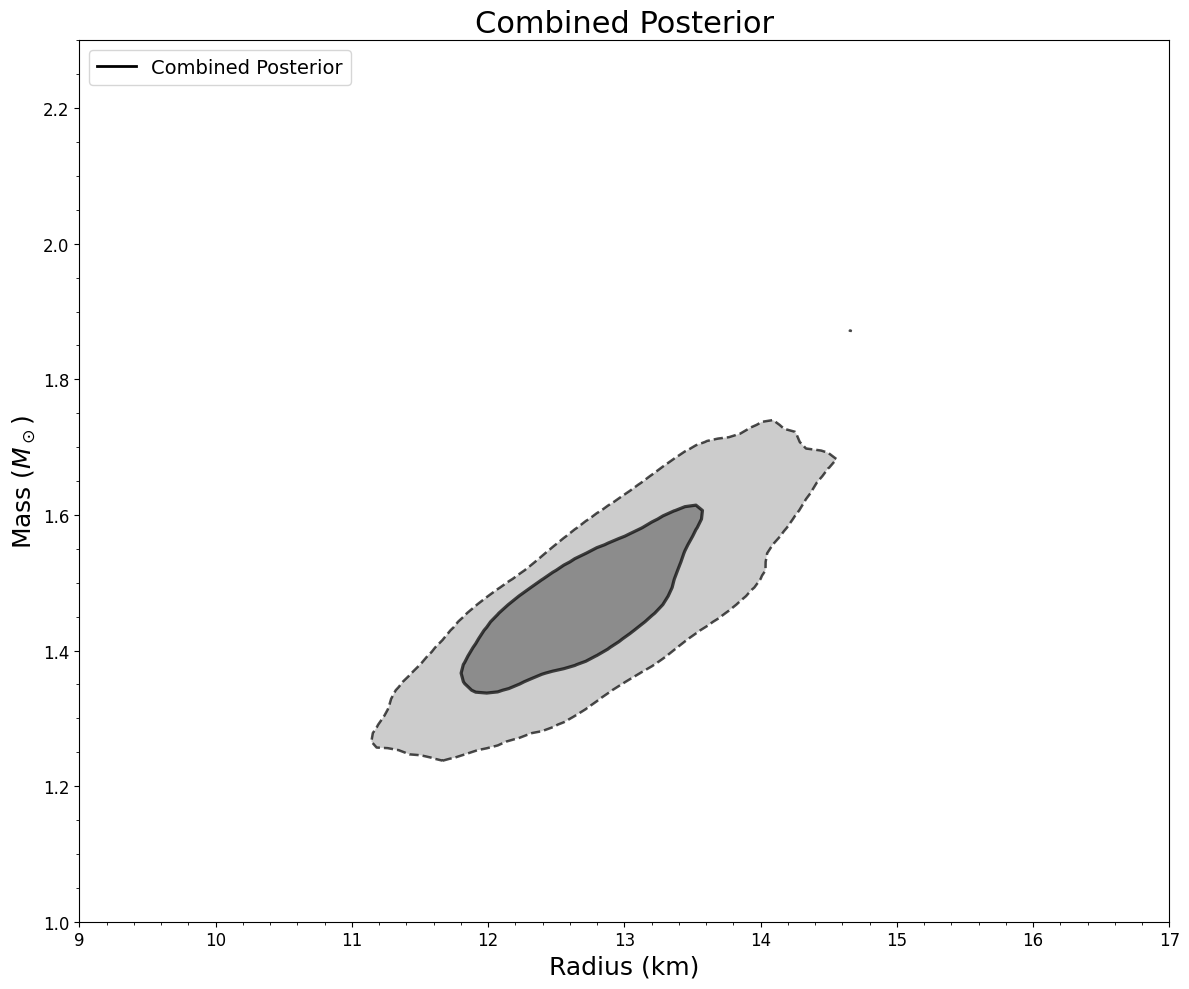

Selected Model: Combined Posterior
Mass: 1.464 (+0.092/-0.086) M_sun
Radius: 12.698 (+0.639/-0.561) km


In [ ]:
# Select which models to plot by specifying any number of keys.
selected_keys = ["combined_posterior"]  # Example: ["ST_PST19", "2spot", "combined_posterior"]

# ------------------------------------------------------------
# HDR level computation
# ------------------------------------------------------------
def compute_hdr_levels(pdf, probs=(0.68, 0.95)):

    flat = pdf.ravel()
    idx = np.argsort(flat)[::-1]
    sorted_pdf = flat[idx]

    cumsum = np.cumsum(sorted_pdf)
    cumsum /= cumsum[-1]

    levels = []
    for p in probs:
        levels.append(sorted_pdf[np.searchsorted(cumsum, p)])

    return levels

# Plot styling helper
def rgba(color, alpha):
    return mpl.colors.to_rgba(color, alpha)

# Build subplot grid based on number of selections
num_models = len(selected_keys)
if num_models == 0:
    raise ValueError("Please select at least one key in selected_keys.")

if num_models == 1:
    fig, axes = plt.subplots(1, 1, figsize=(12, 10), squeeze=False)
    axes = axes.flatten()
elif num_models <= 3:
    fig, axes = plt.subplots(1, num_models, figsize=(6 * num_models, 10), squeeze=False)
    axes = axes.flatten()
else:
    cols = 2
    rows = int(np.ceil(num_models / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows), squeeze=False)
    axes = axes.flatten()

for ax, selected_key in zip(axes, selected_keys):
    density = g_dict[selected_key]
    label = MODELS[selected_key]["label"]
    lvl68, lvl95 = compute_hdr_levels(density, (0.68, 0.95))

    ax.contourf(
        R_grid, M_grid, density,
        levels=[lvl95, lvl68, density.max()],
        colors=[rgba(MODELS[selected_key]["color"], 0.20), rgba(MODELS[selected_key]["color"], 0.45)],
        antialiased=True
    )

    ax.contour(
        R_grid, M_grid, density,
        levels=[lvl95, lvl68],
        colors=rgba(MODELS[selected_key]["color"], 0.7),
        linewidths=[1.8, 2.3],
        linestyles=['--', '-'],
    )

    ax.set_title(label, fontsize=22)
    ax.set_xlabel("Radius (km)", fontsize=18)
    ax.set_ylabel("Mass ($M_\\odot$)", fontsize=18)
    ax.minorticks_on()
    ax.tick_params(labelsize=12)

    legend_handles = [
        mpl.lines.Line2D([], [], color=MODELS[selected_key]["color"], linewidth=2, label=label)
    ]
    ax.legend(
        handles=legend_handles,
        fontsize=14,
        loc='upper left',
        frameon=True,
        fancybox=True,
        framealpha=0.8
    )

# Hide unused axes if any
for ax in axes[num_models:]:
    ax.axis('off')

plt.tight_layout()
plt.ylim(1.0,2.3)
plt.show()

# If exactly one model is selected, also compute and print its marginals
if num_models == 1:
    density = g_dict[selected_keys[0]]
    P_R = np.trapz(density, M_grid, axis=0)
    P_R /= np.trapz(P_R, R_grid)

    P_M = np.trapz(density, R_grid, axis=1)
    P_M /= np.trapz(P_M, M_grid)

    def compute_quantiles(grid, pdf):
        cdf = np.cumsum(pdf) * (grid[1] - grid[0])
        cdf /= cdf[-1]
        return np.interp([0.16, 0.5, 0.84], cdf, grid)

    R_q16, R_q50, R_q84 = compute_quantiles(R_grid, P_R)
    M_q16, M_q50, M_q84 = compute_quantiles(M_grid, P_M)

    label = MODELS[selected_keys[0]]["label"]
    print(f"Selected Model: {label}")
    print(f"Mass: {M_q50:.3f} (+{M_q84 - M_q50:.3f}/-{M_q50 - M_q16:.3f}) M_sun")
    print(f"Radius: {R_q50:.3f} (+{R_q84 - R_q50:.3f}/-{R_q50 - R_q16:.3f}) km")